# Antenna Design Using Deep Learning


In [ ]:
# Imports
import torch, os, os.path as osp
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import numpy as np
import scipy.io
print(torch.cuda.is_available())

import torch
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

True


Import the data file. Here the training and test data are stored in matlab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
filepath = '/content/drive/MyDrive/Dataset_antenna_large1.mat'

Mounted at /content/drive


Split the training and test data set accordingly. The function returns dataloader that splits the data according to the batch size.

In [ ]:
# API to load the saved dataset file
def get_dataloader_from_pth(file_name,batch_size=4,set_name='train'):
    print('loading '+set_name+' data....')

    mat = scipy.io.loadmat(file_name)

    #tset train split
    xdata= mat['XTrain1'] # for filepath 2
    # xdata = mat['xdata']
    xtrain = xdata[0:100000,:,:,:]
    xval   = xdata[100000:150000,:,:,:]
    xtest  = xdata[150000:200000,:,:,:]


    ydata = mat['YTrain'] # for filepath 2
    # ydata = mat['ydata']
    ytrain = ydata[:,0:100000].T
    yval   = ydata[:,100000:150000].T
    ytest  = ydata[:,150000:200000].T
    if (set_name == 'train'):
      contents = {"x": torch.Tensor(xtrain),"y": torch.Tensor(ytrain)}
    elif (set_name == 'test'):
      contents = {"x": torch.Tensor(xtest),"y": torch.Tensor(ytest)}
    else:
      contents = {"x": torch.Tensor(xval),"y": torch.Tensor(yval)}


    # create dataset and dataloader
    dataset = torch.utils.data.TensorDataset(contents['x'], contents['y'])
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
    print(set_name+' data loading complete')

    return dataloader

trainloader = get_dataloader_from_pth(filepath,batch_size=128, set_name = 'train')
valloader   = get_dataloader_from_pth(filepath,batch_size=128, set_name = 'val')
testloader  = get_dataloader_from_pth(filepath,batch_size=128, set_name = 'test')


loading train data....
train data loading complete
loading val data....
val data loading complete
loading test data....
test data loading complete


# Forward Network

Load the best forward network -- i.e initialise the network and the optimizer used while training the forward network. Load using state.load

In [ ]:
num_filters = [1,64,128,256,1000,500,81]
kernels  = [5,5,5,3,3,3,3]
class Net_big(nn.Module):
  def __init__(self):
      super(Net_big, self).__init__()

      #padding=(1,1)
      # self.pool = nn.MaxPool2d(kernel_size=2, stride=1)
      self.conv1  = nn.Conv2d(in_channels=num_filters[0],  out_channels = num_filters[1], kernel_size=kernels[0],padding = 'same')
      self.conv2  = nn.Conv2d(in_channels=num_filters[1],  out_channels = num_filters[1], kernel_size=kernels[1],padding='same')
      self.conv3  = nn.Conv2d(in_channels=num_filters[1],  out_channels = num_filters[1], kernel_size=kernels[2],padding='same')
      self.conv4  = nn.Conv2d(in_channels=num_filters[1],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv5  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv6  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv7  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv8  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[2], kernel_size=kernels[3],padding='same')
      self.conv9  = nn.Conv2d(in_channels=num_filters[2],  out_channels = num_filters[3], kernel_size=kernels[4],padding='same')
      self.conv10  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[4],padding='same')
      self.conv11  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv12  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv13  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv14  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv15  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')
      self.conv16  = nn.Conv2d(in_channels=num_filters[3],  out_channels = num_filters[3], kernel_size=kernels[5],padding='same')


      self.fc17 = nn.Linear(in_features=num_filters[3]*12*12, out_features=num_filters[4])
      self.fc18 = nn.Linear(in_features=num_filters[4], out_features=num_filters[5])
      self.fc19 = nn.Linear(in_features=num_filters[5], out_features=num_filters[6])


      self.bn1  = nn.BatchNorm2d(num_features=num_filters[1])
      self.bn2  = nn.BatchNorm2d(num_features=num_filters[1])
      self.bn3  = nn.BatchNorm2d(num_features=num_filters[1])
      self.bn4  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn5  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn6  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn7  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn8  = nn.BatchNorm2d(num_features=num_filters[2])
      self.bn9  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn10  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn11  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn12  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn13  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn14  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn15  = nn.BatchNorm2d(num_features=num_filters[3])
      self.bn16  = nn.BatchNorm2d(num_features=num_filters[3])


      self.bn17  = nn.BatchNorm1d(num_features=num_filters[4])
      self.bn18 = nn.BatchNorm1d(num_features=num_filters[5])
      self.bn19 = nn.BatchNorm1d(num_features=num_filters[6])

      self.dropout = nn.Dropout(0.4)

  def forward(self, x):
      x = F.leaky_relu(self.bn1(self.conv1(x)))
      x = F.leaky_relu(self.bn2(self.conv2(x)))
      x = F.leaky_relu(self.bn3(self.conv3(x)))
      x = F.leaky_relu(self.bn4(self.conv4(x)))
      x = F.leaky_relu(self.bn5(self.conv5(x)))
      x = F.leaky_relu(self.bn6(self.conv6(x)))
      x = F.leaky_relu(self.bn7(self.conv7(x)))
      x = F.leaky_relu(self.bn8(self.conv8(x)))
      x = F.leaky_relu(self.bn9(self.conv9(x)))
      x = F.leaky_relu(self.bn10(self.conv10(x)))
      x = F.leaky_relu(self.bn11(self.conv11(x)))
      x = F.leaky_relu(self.bn12(self.conv12(x)))
      x = F.leaky_relu(self.bn13(self.conv13(x)))
      x = F.leaky_relu(self.bn14(self.conv14(x)))
      x = F.leaky_relu(self.bn15(self.conv15(x)))
      x = F.leaky_relu(self.bn16(self.conv16(x)))


      #x = (F.relu(self.bn4(self.conv4(x))))
      #x = self.pool(F.relu(self.bn5(self.conv5(x))))
      #x = (F.relu(self.bn6(self.conv6(x))))
      #x = F.avg_pool2d(x, kernel_size=x.shape[2:])
      #x = x.view(x.shape[0], -1)
      x = torch.flatten(x, 1)
      x = self.dropout(F.leaky_relu(self.bn17(self.fc17(x))))
      x = F.leaky_relu(self.bn18(self.fc18(x)))

      #x = F.relu(self.fc2(x))
      x = self.fc19(x)
      return x
net_big = Net_big()
  # transfer the model to GPU
if torch.cuda.is_available():
    net_big = net_big.cuda()


In [ ]:
for parameter in net_big.parameters():
    print(parameter)

In [ ]:
# criterion = nn.MSELoss()
# optimizer = optim.NAdam(net_xlarge.parameters() , lr=0.001)

# filepath4 = '/content/drive/MyDrive/modelxlarge28.pth'
# state = torch.load(filepath4)
# net_xlarge.load_state_dict(state['state_dict'])
# optimizer.load_state_dict(state['optimizer'])


criterion = nn.MSELoss()
optimizer = optim.NAdam(net_big.parameters() , lr=0.001)

filepath4 = '/content/drive/MyDrive/Model_large15.pth'
state = torch.load(filepath4)
net_big.load_state_dict(state['state_dict'])
optimizer.load_state_dict(state['optimizer'])
net_big.eval()

Net_big(
  (conv1): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (conv3): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv8): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv13): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=

In [ ]:
for parameter in net_big.parameters():
    print(parameter)

# Check Forward

In [ ]:
def cmp_test(testloader,net,i):
  running_loss = 0.0
  with torch.no_grad():
      # for data in tqdm(testloader,disable=True):
      for data in testloader:
          antenna, spectrum = data

          if torch.cuda.is_available():
              antenna, spectrum = antenna.cuda(), spectrum.cuda()

          # forward + backward + optimize
          prediction = net(antenna)
          loss = criterion(prediction, spectrum)

          # print statistics
          running_loss += loss.item()

          plt.plot(spectrum[i,:].cpu())
          plt.plot(prediction[i,:].cpu())
          plt.legend(['True','Prediction'])
          #plt.savefig('Test1.png')
          plt.show()

          break;

  return running_loss / (len(testloader))

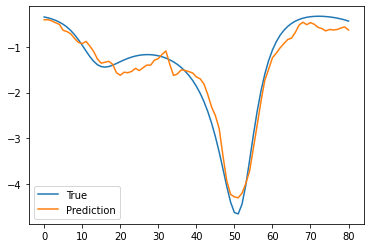

0.00233328723541611

In [ ]:
cmp_test(testloader,net_big,15)

# Inverse Design training

In [ ]:
trainloader = get_dataloader_from_pth(filepath,batch_size=1024, set_name = 'train')
valloader   = get_dataloader_from_pth(filepath,batch_size=1024, set_name = 'val')
testloader  = get_dataloader_from_pth(filepath,batch_size=1024, set_name = 'test')


loading train data....
train data loading complete
loading val data....
val data loading complete
loading test data....
test data loading complete


In [ ]:
len(trainloader)

98

In [ ]:
num_filters=[81,1054,512,144]

def ualayer(x):
    return 0.5*(1 + torch.tanh((x-0.5)*15))


class Net_inverse(nn.Module):
    def __init__(self):
        super(Net_inverse, self).__init__()

        self.fc6 = nn.Linear(in_features=num_filters[0], out_features=num_filters[1])
        self.fc7 = nn.Linear(in_features=num_filters[1], out_features=num_filters[2])
        self.fc8 = nn.Linear(in_features=num_filters[2], out_features=num_filters[3])

        self.bn6 = nn.BatchNorm1d(num_features=num_filters[1])
        self.bn7 = nn.BatchNorm1d(num_features=num_filters[2])

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):

        x = self.dropout(F.leaky_relu(self.bn6(self.fc6(x))))
        x = self.dropout(F.leaky_relu(self.bn7(self.fc7(x))))
        x = ualayer(F.leaky_relu(self.fc8(x)))
        #x = F.relu(self.fc2(x))
        # x = self.fc8(x)
        # x = ualayer(x)
        return x
################### DO NOT EDIT THE BELOW CODE!!! #######################

#net = ResNet()
net_inv = Net_inverse()

# transfer the model to GPU
if torch.cuda.is_available():
    net_inv = net_inv.cuda()

In [ ]:
criterion1 = nn.MSELoss()
optimizer1 = optim.RAdam(net_inv.parameters() , lr=0.001)
alpha = 5.8
def loss_xu(spectrum_pred, spectrum, antenna_pred, antenna, alpha):
    loss = torch.mean((spectrum_pred - spectrum)**2) + alpha*torch.mean((antenna_pred - antenna)**2)
    spec_loss = torch.mean((spectrum_pred - spectrum)**2)
    design_loss = alpha*torch.mean((antenna_pred - antenna)**2)

    return loss, spec_loss, design_loss

def train_inverse(epoch, trainloader, optimizer1, criterion1):
    running_loss = 0.0
    for i, data in enumerate(tqdm(trainloader,disable=True), 0):
        # get the inputs

        antenna, spectrum = data

        if torch.cuda.is_available():
            antenna, spectrum = antenna.cuda(), spectrum.cuda()

        # zero the parameter gradients
        optimizer1.zero_grad()
        # forward + backward + optimize
        ant_pred = net_inv(spectrum)
        # ant_pred.Size()
        # ant_pred.shape[0]
        antenna_pred = ant_pred.reshape(ant_pred.shape[0],1,12,12)
        spectrum_pred = net_big(antenna_pred)
        # loss1 = criterion1(spectrum_pred, spectrum)
        loss1, spec_loss, design_loss = loss_xu(spectrum_pred, spectrum, antenna_pred, antenna, alpha)
        loss1.backward()
        optimizer1.step()

        # print statistics
        running_loss += loss1.item()

    return running_loss / (len(trainloader)), spec_loss, design_loss

def test_inverse(valloader,criterion1,net_inv,net):
  running_loss = 0.0
  with torch.no_grad():
    for data in tqdm(valloader,disable=True):
        antenna, spectrum = data

        if torch.cuda.is_available():
            antenna, spectrum = antenna.cuda(), spectrum.cuda()

        # forward + backward + optimize
        ant_pred = net_inv(spectrum)
        antenna_pred = ant_pred.reshape(ant_pred.shape[0],1,12,12)
        spectrum_pred = net(antenna_pred)
        # loss1 = criterion1(spectrum_pred, spectrum)
        # loss1 = loss_xu(spectrum_pred, spectrum, antenna_pred, antenna, alpha)
        loss1, spec_loss, design_loss = loss_xu(spectrum_pred, spectrum, antenna_pred, antenna, alpha)


        # print statistics
        running_loss += loss1.item()
  return running_loss / (len(testloader)), spec_loss, design_loss


In [ ]:
import time
ts=time.time()
torch.cuda.empty_cache()
print('\nStart Training')
# os.makedirs('./models', exist_ok=True)
model_data_save_path = '/content/drive/MyDrive/My_models'
os.makedirs(model_data_save_path, exist_ok=True)

#import timeit
epoch_start = 0
num_epochs = 2       # desired number of training epochs.
val_loss_inv=np.empty(num_epochs,float)
train_loss_inv=np.empty(num_epochs,float)
train_spec_loss = np.empty(num_epochs,float)
train_des_loss = np.empty(num_epochs,float)
val_spec_loss = np.empty(num_epochs,float)
val_des_loss = np.empty(num_epochs,float)


for epoch in range(epoch_start,num_epochs):  # loop over the dataset multiple times
    #print('\nepoch ', epoch + 1)
    train_loss_inv[epoch], train_spec_loss[epoch], train_des_loss[epoch] = train_inverse(epoch,trainloader, optimizer1, criterion1)
    val_loss_inv[epoch], val_spec_loss[epoch], val_des_loss[epoch]  =  test_inverse(valloader,criterion1,net_inv,net_big)

    # print('\nepoch %d training loss: %.3f  validation loss: %.3f' % (epoch + 1, train_loss_inv[epoch], val_loss_inv[epoch] ))
    print('\nepoch %d training loss: %.3f  validation loss: %.3f TSL: %.3f TDL: %.3f VSL: %.3f VDL: %.3f' % (epoch + 1, train_loss_inv[epoch], val_loss_inv[epoch],train_spec_loss[epoch], train_des_loss[epoch], val_spec_loss[epoch], val_des_loss[epoch] ))

#     if (epoch % 50==0):
#       file_save = '/content/drive/MyDrive/My_models/model_inv_ualargem15ua'+str(epoch)+'.pth'
#       state = {
#               'epoch': epoch,
#               'state_dict': net_inv.state_dict(),
#               'optimizer': optimizer1.state_dict(),
#               }
#       torch.save(state,file_save)

#     # save model checkpoint
# np.savetxt('/content/drive/MyDrive/My_models/loss_log_ua'+str(num_epochs-1)+'.txt', (train_loss_inv, val_loss_inv, train_spec_loss, train_des_loss, val_spec_loss, val_des_loss))
print('Finished Training')
#test(trainloader, net, 'training')

te=time.time()
te-ts


Start Training

epoch 1 training loss: 7.247  validation loss: 5.968 TSL: 3.151 TDL: 2.764 VSL: 3.169 VDL: 2.766

epoch 2 training loss: 5.516  validation loss: 5.247 TSL: 2.598 TDL: 2.582 VSL: 2.633 VDL: 2.582
Finished Training


665.3278460502625

In [ ]:
for parameter in net_inv.parameters():
    print(parameter)

In [ ]:
# Commands used to reset the layers of the trained network
for layers in net_inv.children():
    if hasattr(layers, 'reset_parameters'):
        layers.reset_parameters()

In [ ]:
for parameter in net_inv.parameters():
    print(parameter)

In [ ]:
criterion1 = nn.MSELoss()
optimizer1 = optim.NAdam(net_inv.parameters() , lr=0.001)

filepath4 = '/content/drive/MyDrive/My_models/model_inv_ualargem10xuuafd50.pth'
state = torch.load(filepath4)
net_inv.load_state_dict(state['state_dict'])
optimizer1.load_state_dict(state['optimizer'])
net_inv.eval()

NameError: ignored

In [ ]:
for parameter in net_inv.parameters():
    print(parameter)

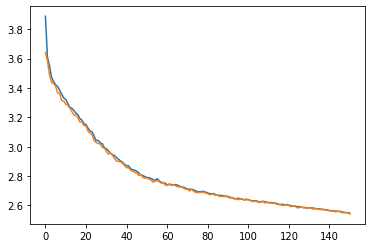

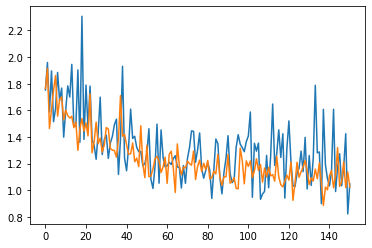

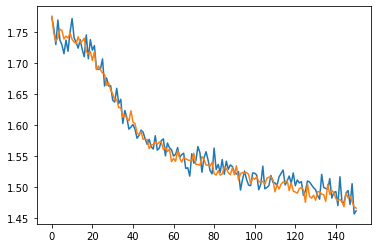

151

In [ ]:
import matplotlib.pyplot as plt
# .pyplot as plt
tot_plot = plt.plot(train_loss_inv)
tot_plot = plt.plot(val_loss_inv)
plt.show()

tot_spec_plot= plt.plot(train_spec_loss)
tot_spec_plot= plt.plot(val_spec_loss)
plt.show()

tot_des_plot= plt.plot(train_des_loss)
tot_des_plot= plt.plot(val_des_loss)
plt.show()


len(train_loss_inv)




In [ ]:
criterion1 = nn.MSELoss()
optimizer1 = optim.NAdam(net_inv.parameters() , lr=0.001)

filepath5 = '/content/drive/MyDrive/model_inv_xlargexu20.pth'
state = torch.load(filepath5)
net_inv.load_state_dict(state['state_dict'])
optimizer1.load_state_dict(state['optimizer'])


In [ ]:
import matplotlib.pyplot as plt
def cmp_test(test_data,criterion1,net_inv,net):
  running_loss = 0.0
  with torch.no_grad():
      for data in tqdm(test_data,disable=True):
          antenna, spectrum = data

          if torch.cuda.is_available():
              antenna, spectrum = antenna.cuda(), spectrum.cuda()

          # forward + backward + optimize
          ant_pred = net_inv(spectrum)
          antenna_pred = ant_pred.reshape(ant_pred.shape[0],1,12,12)
          # imgplot = plt.imshow(np.array(antenna_pred[2,0,:,:]))
          # plt.show()
          # print(antenna_pred[0,:,:,:])
          spectrum_pred = net(antenna_pred)
          loss1 = criterion1(spectrum_pred, spectrum)
          # loss1 = loss_xu(spectrum_pred, spectrum, antenna_pred, antenna, alpha)

          # print statistics
          running_loss += loss1.item()
          #spectrum_pred = spectrum_pred.T
          #spectrum = spectrum.T
          for i in range(2):
            imgplot = plt.plot(spectrum[i,:].cpu())
            imgplot = plt.plot(spectrum_pred[i,:].cpu())
            # imgplot = plt.imshow((antenna_pred[i,0,:,:].cpu()))

            plt.show()
          # break;
          # for i in range(2):
            # imgplot = plt.plot(spectrum[i,:].cpu())
            # imgplot = plt.plot(spectrum_pred[i,:].cpu())
            imgplot1 = plt.imshow((antenna_pred[i,0,:,:].cpu()))

            plt.show()
            # print(antenna_pred[i,:,:,:])
          break;

  return running_loss / (len(testloader)), spectrum

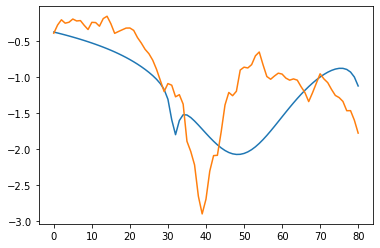

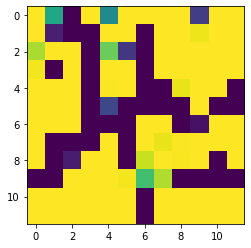

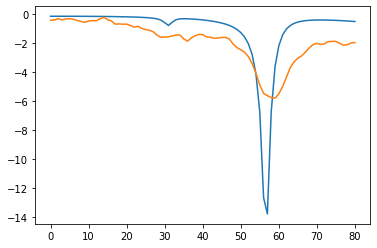

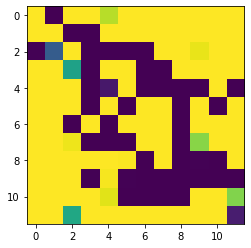

In [ ]:
loss, spec = cmp_test(testloader,criterion1,net_inv,net_big)

In [ ]:
for parameter in net_inv.parameters():
    print(parameter)

Parameter containing:
tensor([[-0.0172, -0.1089, -0.0475,  ...,  0.2540,  0.2062,  0.2021],
        [ 0.1692, -0.0288,  0.1037,  ...,  0.1472,  0.0591,  0.1234],
        [ 0.0906,  0.0207, -0.0213,  ..., -0.0427, -0.0595, -0.0234],
        ...,
        [ 0.0786, -0.0805, -0.0403,  ..., -0.2232, -0.2642, -0.1892],
        [-0.1064, -0.1377,  0.0427,  ...,  0.1067,  0.1631,  0.0231],
        [-0.1220, -0.0510, -0.0472,  ...,  0.0473,  0.0224,  0.0788]],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([-0.0417,  0.0966,  0.0157,  ..., -0.0382, -0.0021,  0.1114],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[-0.0126, -0.1281,  0.0501,  ..., -0.1157, -0.0122,  0.1345],
        [ 0.1158,  0.0193, -0.0549,  ..., -0.1537, -0.0097, -0.0577],
        [ 0.0899,  0.1262,  0.0872,  ...,  0.0619,  0.1635,  0.1793],
        ...,
        [ 0.1222,  0.1244, -0.1037,  ..., -0.0434, -0.1708,  0.1352],
        [ 0.1158,  0.0842, -0.0280,  ...,  0.0433,

In [ ]:
# Commands used to reset the layers of the trained network
for layers in net.children():
    if hasattr(layers, 'reset_parameters'):
        layers.reset_parameters()

